# Sensibilidades (Greeks) de opciones: aproximación vs Black-Scholes

**Nombre:** Roberto Carlos Guzmán Orduño  
**Materia:** Simulación de Procesos Financieros

---

## Parte 1: Observación

Datos de las tres opciones (la acción cotiza en $100):

| Opción | K | T | Prima | Delta | Vega | Theta |
|---|---|---|---|---|---|---|
| A | 90 | 1/12 | 12 | 0.85 | 0.05 | -0.10 |
| B | 100 | 3/12 | 8 | 0.50 | 0.25 | -0.03 |
| C | 120 | 1 | 5 | 0.20 | 0.40 | -0.01 |

**1. ¿Cuál es más sensible al precio de la acción?**
La A, tiene la delta mas alta (0.85). Si la accion sube $1 la opcion sube casi $0.85.

**2. ¿Cuál es más sensible a la volatilidad?**
La C, tiene la vega mas grande (0.40) y ademas le quedan 12 meses de vida.

**3. ¿Cuál se deteriora más rápido con el tiempo?**
La A, tiene la theta mas negativa (-0.10) y vence en un mes.

**4. ¿Cuál se parece más a la acción?**
La A, su delta es la mas cercana a 1 y ya esta dentro del dinero (K = 90).

**5. ¿Cuál depende más de que ocurra un evento importante?**
La C, esta muy fuera del dinero (K = 120) y la accion tiene que subir mucho para que valga algo.

## Parte 2: Escenarios de mercado

**Escenario A (sube poco a poco, la volatilidad no cambia):**
Compraria la A, tiene la delta mas alta y casi no depende de la volatilidad. Evitaria la C, con una subida lenta dificil llega a 120 y su delta de 0.20 gana poco.

**Escenario B (anuncio en dos semanas, cambio brusco sin saber la dirección):**
Compraria la B, esta en el dinero y tiene buena vega, asi que le conviene un movimiento grande y le da tiempo al anuncio. Evitaria la A porque se comporta casi como la accion y tiene poca vega.

**Escenario C (la acción se mantiene muy estable):**
Compraria la A, ya tiene $10 de valor intrinseco y solo arriesga como $2 de valor en el tiempo. Evitaria la C, si el precio no se mueve pierde casi toda su prima y una baja en la volatilidad le pega por su vega alta.

**Escenario D (caída significativa):**
Las tres son calls asi que todas pierden. Evitaria la A porque tiene la delta mas alta y es la que mas pierde. La C seria la menos mala porque solo pierdo la prima de $5. Lo ideal seria una put.

**Escenario E (el mercado subestima la incertidumbre):**
Compraria la C, tiene la vega mas alta (0.40) y si sube la volatilidad es la que mas gana. Evitaria la A, su vega es de solo 0.05.

## Parte 3: Simulación

### Datos iniciales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

meses = ["Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre"]
precio = [100, 102, 101, 105, 103, 110]
vol = [20, 25, 30, 28, 22, 20]

r = 0.05
K = 100
V0 = 6.8887
delta = 0.5977
gamma = 0.02736
vega = 0.2814
theta = -8.116
dt = 1/12

df = pd.DataFrame({"Mes": meses, "Precio": precio, "Volatilidad": vol})
df

,Mes,Precio,Volatilidad
0,Mayo,100,20
1,Junio,102,25
2,Julio,101,30
3,Agosto,105,28
4,Septiembre,103,22
5,Octubre,110,20


**Interpretación:** Aqui puse los datos del ejercicio. La volatilidad la deje en puntos porcentuales porque la vega de 0.2814 es el cambio por cada 1% de volatilidad. El precio sube de 100 a 110 y la volatilidad llega a 30% en julio y luego baja a 20%.

### Valor aproximado con Greeks

In [2]:
df["dS"] = df["Precio"].diff()
df["dsigma"] = df["Volatilidad"].diff()

V = [V0]
for i in range(1, len(df)):
    dS = df.loc[i, "dS"]
    dsig = df.loc[i, "dsigma"]
    nuevo = V[i-1] + delta*dS + 0.5*gamma*dS**2 + vega*dsig + theta*dt
    V.append(nuevo)

df["Valor Greeks"] = V
df.round(4)

,Mes,Precio,Volatilidad,dS,dsigma,Valor Greeks
0,Mayo,100,20,NaN,NaN,6.8887
1,Junio,102,25,2.0,5.0,8.8695
2,Julio,101,30,-1.0,5.0,9.0161
3,Agosto,105,28,4.0,-2.0,10.3867
4,Septiembre,103,22,-2.0,-6.0,6.8813
5,Octubre,110,20,7.0,-2.0,10.4964


**Interpretación:** Use las greeks del dia inicial siempre iguales y cada valor sale del anterior. La opcion pasa de 6.89 en mayo a 10.50 en octubre. Sube hasta agosto por el precio y la volatilida, y en septiembre baja porque la volatilidad cae 6 puntos.

### Valor de la call con simulación (10,000 escenarios)

In [3]:
np.random.seed(1)
M = 10000
T = [6/12, 5/12, 4/12, 3/12, 2/12, 1/12]

valores = []
for S, s, t in zip(df["Precio"], df["Volatilidad"]/100, T):
    Z = np.random.normal(0, 1, M)
    ST = S*np.exp((r - 0.5*s**2)*t + s*np.sqrt(t)*Z)
    payoff = np.maximum(ST - K, 0)
    valores.append(np.exp(-r*t)*payoff.mean())

tabla_bs = pd.DataFrame({
    "Mes": meses,
    "Precio": precio,
    "Volatilidad": vol,
    "Tiempo restante": ["6/12", "5/12", "4/12", "3/12", "2/12", "1/12"],
    "Valor Black-Scholes": valores
})
tabla_bs.round(4)

,Mes,Precio,Volatilidad,Tiempo restante,Valor Black-Scholes
0,Mayo,100,20,6/12,6.9522
1,Junio,102,25,5/12,8.7854
2,Julio,101,30,4/12,8.0971
3,Agosto,105,28,3/12,9.5301
4,Septiembre,103,22,2/12,5.8575
5,Octubre,110,20,1/12,10.5756


**Interpretación:** Para cada mes simule 10,000 precios finales con su precio y volatilidad, calcule el pago de la call y lo traje a valor presente. En mayo salio 6.95, casi igual al 6.8887 del ejercicio, asi que la simulacion esta bien. Siempre queda una diferencia chica por el azar.

### Comparación

In [4]:
comp = pd.DataFrame({
    "Mes": meses,
    "Greeks": df["Valor Greeks"],
    "Black-Scholes": tabla_bs["Valor Black-Scholes"]
})
comp["Error Absoluto"] = abs(comp["Greeks"] - comp["Black-Scholes"])
comp.loc[0, "Error Absoluto"] = np.nan
comp.style.format({"Greeks": "{:.4f}", "Black-Scholes": "{:.4f}", "Error Absoluto": "{:.4f}"}, na_rep="-")

,Mes,Greeks,Black-Scholes,Error Absoluto
0,Mayo,6.8887,6.9522,-
1,Junio,8.8695,8.7854,0.0841
2,Julio,9.0161,8.0971,0.9190
3,Agosto,10.3867,9.5301,0.8565
4,Septiembre,6.8813,5.8575,1.0237
5,Octubre,10.4964,10.5756,0.0793


**Interpretación:** En junio y octubre el error es chico (menos de 0.10), pero en julio, agosto y septiembre es de casi 1 dolar. El mayor fue en septiembre (como 1.02). En esos meses los Greeks quedan arriba de la simulacion.

### Gráfica

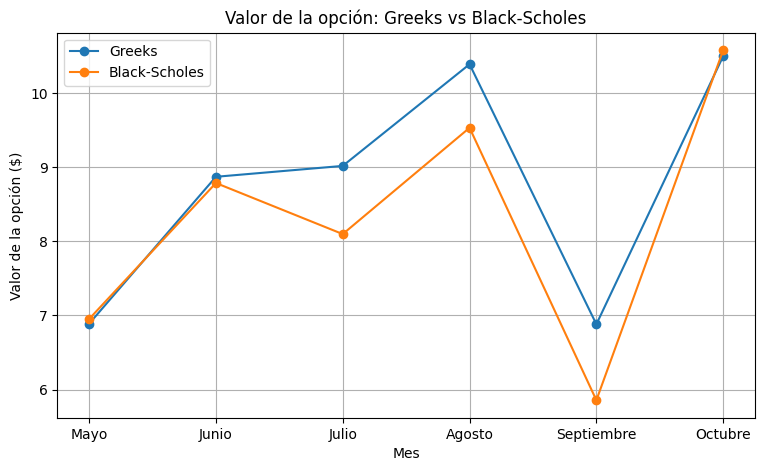

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(meses, comp["Greeks"], marker="o", label="Greeks")
plt.plot(meses, comp["Black-Scholes"], marker="o", label="Black-Scholes")
plt.title("Valor de la opción: Greeks vs Black-Scholes")
plt.xlabel("Mes")
plt.ylabel("Valor de la opción ($)")
plt.legend()
plt.grid(True)
plt.show()

**Interpretación:** Las lineas empiezan y terminan casi juntas, pero de julio a septiembre la de Greeks se separa y queda arriba. Tienen la misma forma pero la de Greeks no describe bien los meses de en medio.

## Preguntas finales

**1. ¿Los greeks iniciales describen con precisión toda la trayectoria?**
No. Sirven bien en junio y octubre, pero en los meses de en medio el error llega a casi $1, entre 9% y 17% del valor de la opcion.

**2. ¿En qué mes apareció el error más grande?**
En septiembre, con un error absoluto de como 1.02.

**3. ¿Qué factor parece contribuir más al error?**
La volatilidad, cambio hasta 6 puntos y la vega se uso siempre igual (0.2814) aunque en realidad cambia con el precio y el tiempo. Delta y gama pesaron menos porque el precio cambio poco.

**4. ¿Por qué los Greeks funcionan mejor para movimientos pequeños que para movimientos grandes?**
Porque son una aproximasion de primer y segundo orden y solo sirven cerca de donde se calcularon. Si el precio o la volatilidad se mueven mucho, la delta, gama y vega ya son otras.

**5. Si la trayectoria fuera mucho más volátil, ¿esperarías errores menores?**
No, mayores. Con mas volatilidad los cambios en precio y volatilidad serian mas grandes y hay es donde mas fallan los Greeks.

**6. Conclusión**
Los Greeks sirven para estimar rapido el cambio de una opcion con movimientos chicos, pero fijos por seis meses el error se acumula, sobre todo por la volatilidad. Para periodos largos conviene recalcular con Black-Scholes o simulacion, o actualizar los Greeks cada mes.